<h1>Pneumonia detection using Convolutional neural networks</h1>

<h1>Objective :</h1>
<p>Pneumonia infection is a serious disease of the lungs with a range of possible causes. Bacteria, viruses or fungi can cause Pneumonia infection. Pneumonia is ranked as eighth leading for causing more no. of deaths in the US, It causes death in children younger than five years of age worldwide. To save precious lives many people humans and technology should interact.<p>

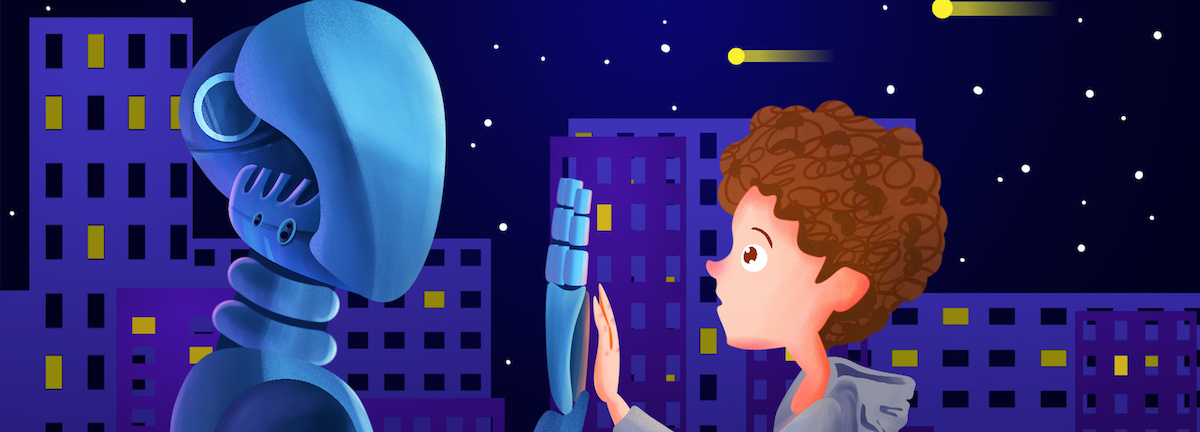


Chest X-rays are used for detecting the Pneumonia infection and to locate the infected area in the lungs.
So, To detect the the pneumonia radiologist have to observe the chest xray and he/she has to update the doctor correctly.
The main objective of this model is to identify if the person has Pneumonia or not with high accuracy so that the person can get treatment as soon as possible. Deep Learning models which are trained correctly by using good datasets can be helpful for doctors.
To train the model for detecting whether the person has pneumonia or not, A Convolutional Neural Network(CNN) is used. The CNN can train the images of chest xrays and then it can predict with high accuracy.



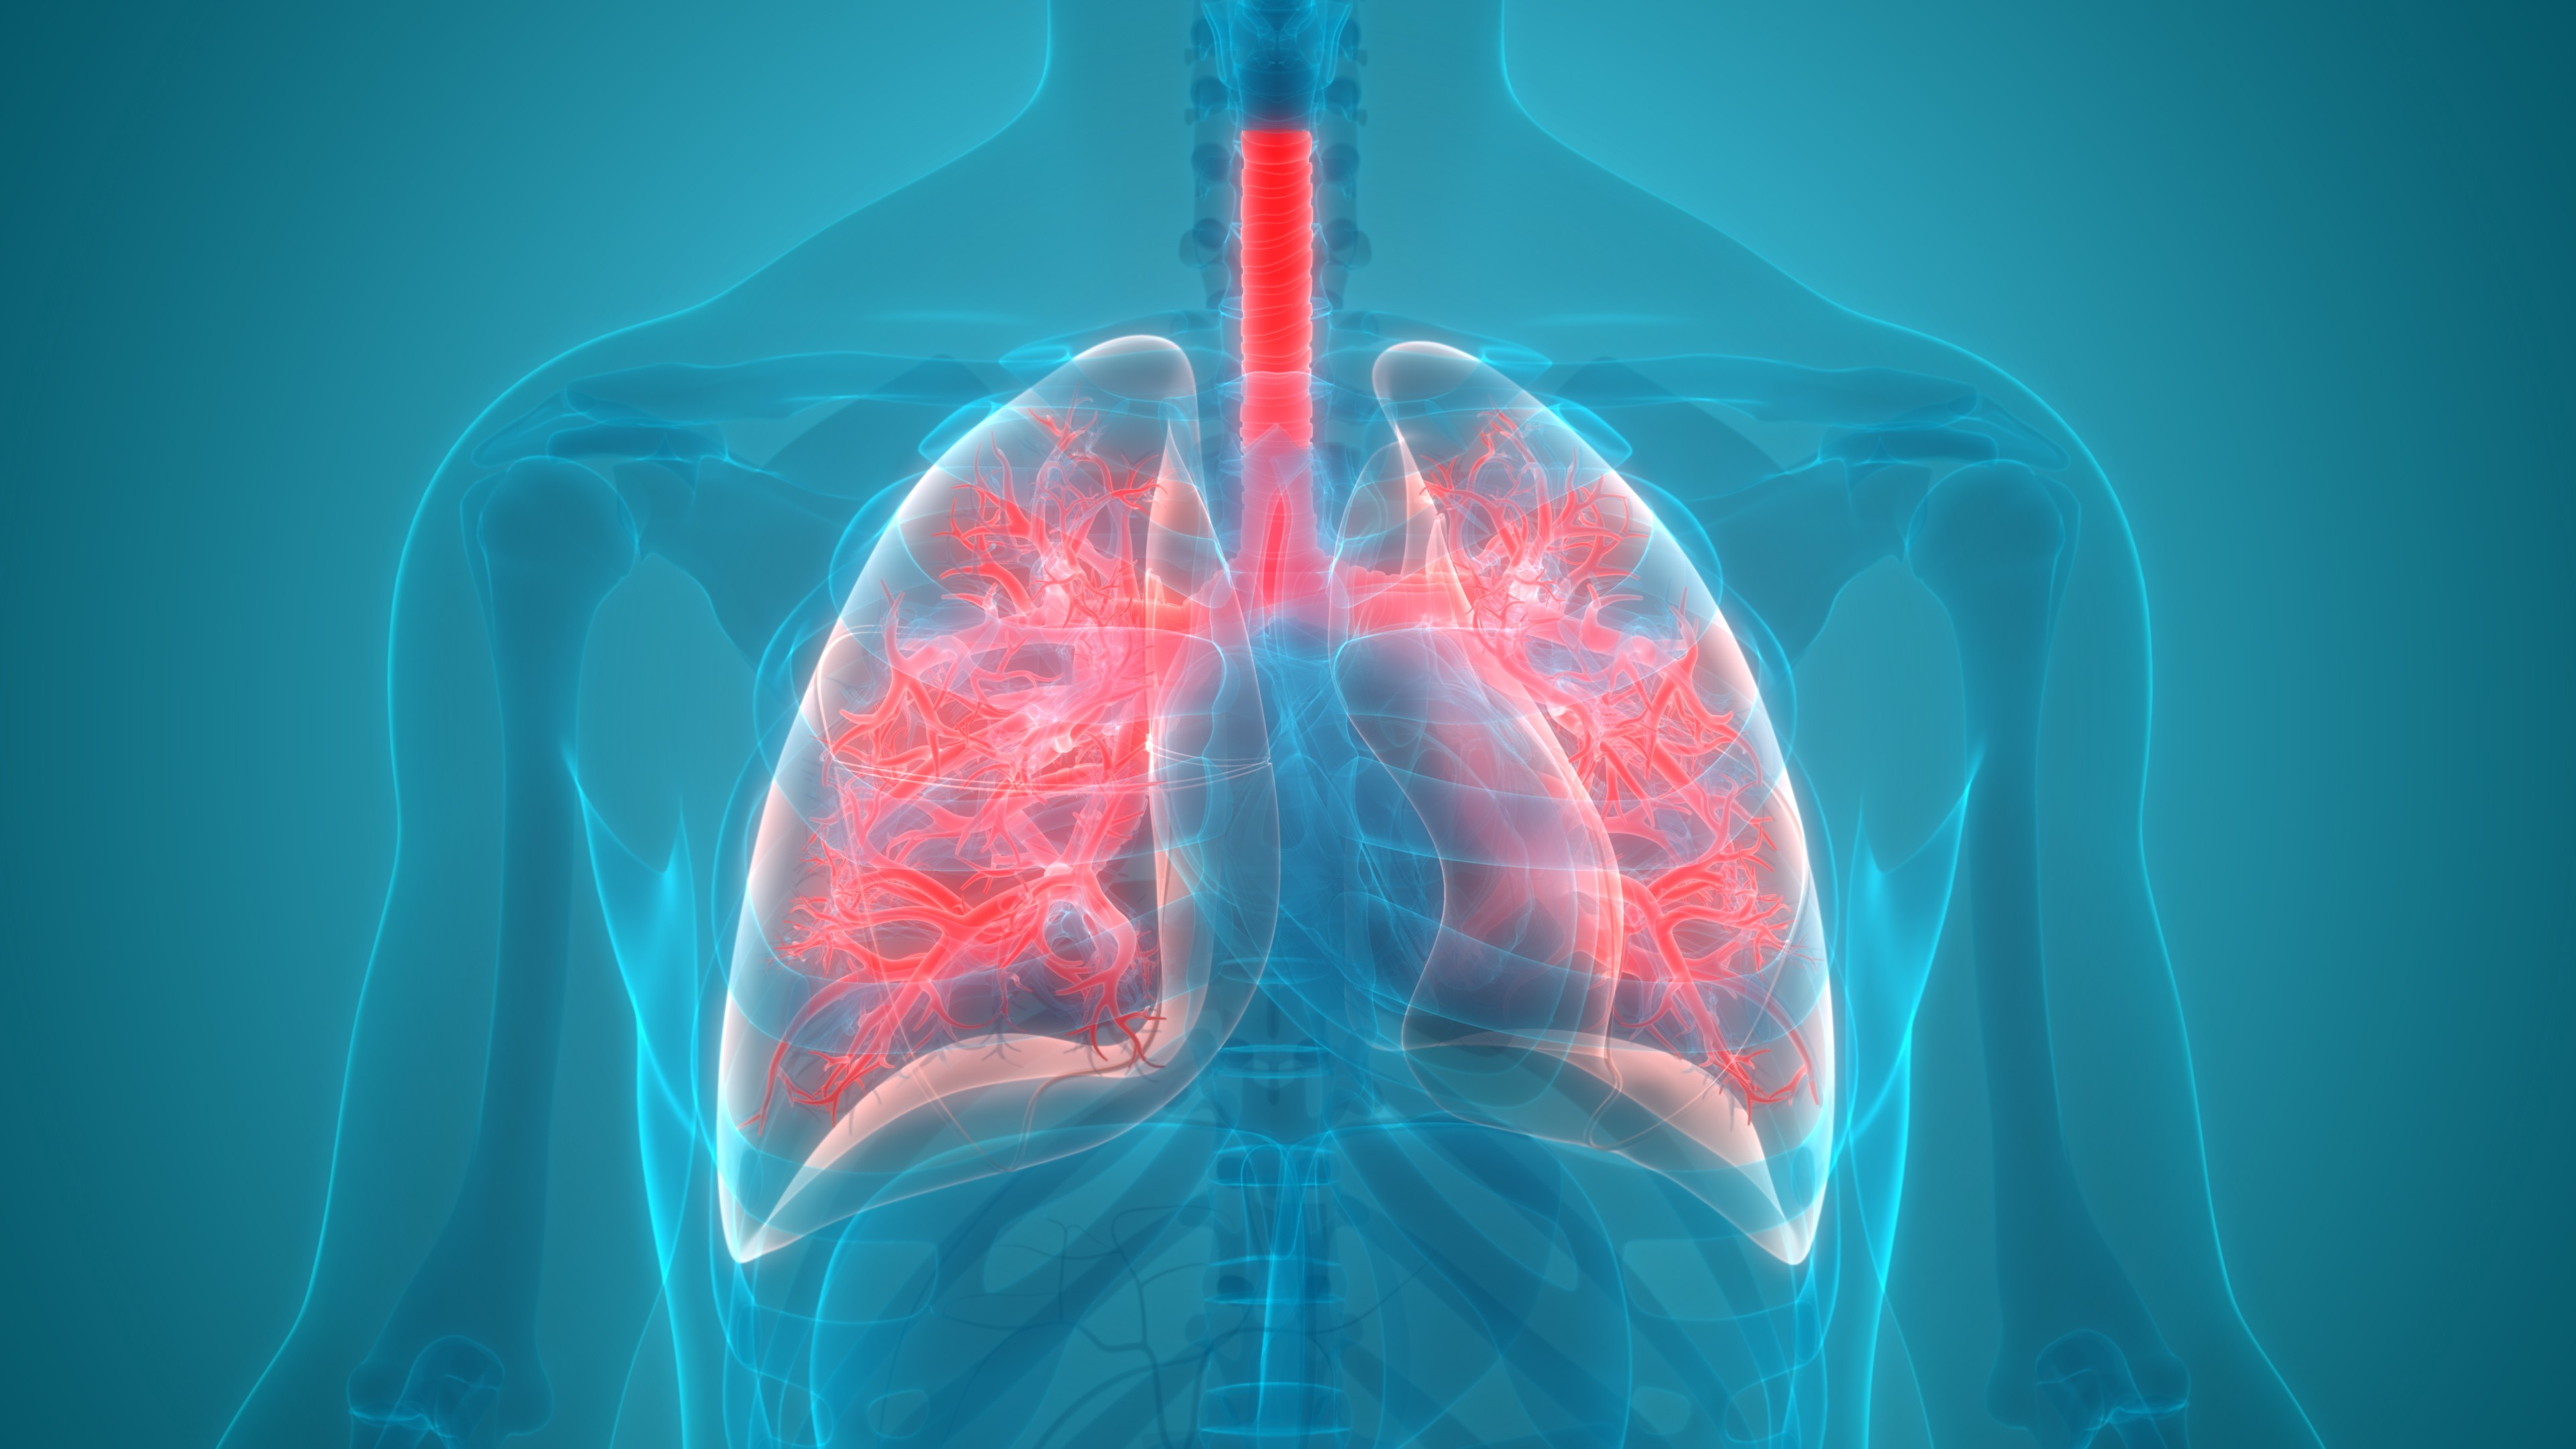

The dataset used here is chest xray dataset which is preprocessed.
You can find the **Dataset** [here.](https://www.kaggle.com/paultimothymooney/chest-xray-pneumonia)

The dataset consists of :


*   5216 training images of which 3815 are of Pneumonia and 1341 are normal images.
*   624 testing images of which 390 are of Pneumonia and 234 are normal.




**Libraries used :**

Numpy : Used for multidimensional arrays.

Matplotlib : Used to visualize data with graphs.

cv2 : OpenCV is used to deal with images.

Keras : It is the interface for Neural Networks and Tensorflow.

In [1]:
from pathlib import Path
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# Reproducibility (results can still vary slightly between hardware/software versions)
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

IMG_SIZE = (300, 300)
BATCH_SIZE = 32
CLASS_NAMES = ["NORMAL", "PNEUMONIA"]  # Keep label 0 = NORMAL and label 1 = PNEUMONIA

# By default, expects a chest_xray folder in the same directory from which Jupyter was started.
# You can set CHEST_XRAY_DIR to use a different dataset location.
DATASET_DIR = Path(os.environ.get("CHEST_XRAY_DIR", "chest_xray")).expanduser().resolve()
TRAIN_DIR = DATASET_DIR / "train"
VAL_DIR = DATASET_DIR / "val"
TEST_DIR = DATASET_DIR / "test"
MODEL_PATH = Path.cwd() / "trained.h5"

print("Dataset directory:", DATASET_DIR)
print("TensorFlow version:", tf.__version__)

Dataset directory: C:\Users\RAKESH\PycharmProjects\CCL_Project\chest_xray
TensorFlow version: 2.21.0


**Dataset structure required**

Place a folder named `chest_xray` in the Jupyter working directory (or set the `CHEST_XRAY_DIR` environment variable). It must contain:

```text
chest_xray/
├── train/
│   ├── NORMAL/
│   └── PNEUMONIA/
├── val/
│   ├── NORMAL/
│   └── PNEUMONIA/
└── test/
    ├── NORMAL/
    └── PNEUMONIA/
```

The training generator must point to `chest_xray/train`, not to the dataset root.

In [2]:
# Augmentation is applied only to training images.
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

# Validation/test images are only rescaled; do not augment evaluation data.
eval_datagen = ImageDataGenerator(rescale=1.0 / 255)

**Training data which is present in drive.**

In [3]:
# Check that the dataset has the expected directory structure before loading it.
for required_dir in [TRAIN_DIR, VAL_DIR, TEST_DIR]:
    if not required_dir.is_dir():
        raise FileNotFoundError(
            f"Required dataset folder was not found: {required_dir}\n"
            "Expected chest_xray/train, chest_xray/val, and chest_xray/test."
        )

for split_dir in [TRAIN_DIR, VAL_DIR, TEST_DIR]:
    missing_classes = [name for name in CLASS_NAMES if not (split_dir / name).is_dir()]
    if missing_classes:
        raise FileNotFoundError(
            f"Missing class folder(s) in {split_dir}: {missing_classes}. "
            f"Each split must contain NORMAL and PNEUMONIA folders."
        )

print("Dataset folder structure looks correct.")

Dataset folder structure looks correct.


Here every image is resized to (300,300)

In [4]:
# IMPORTANT: load from chest_xray/train, not from the chest_xray root.
# Otherwise train/val/test may incorrectly be treated as class labels.
train_generator = train_datagen.flow_from_directory(
    str(TRAIN_DIR),
    classes=CLASS_NAMES,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=True,
    seed=SEED
)

print("Training class mapping:", train_generator.class_indices)
assert train_generator.class_indices == {"NORMAL": 0, "PNEUMONIA": 1}, (
    "Unexpected class mapping. Check the class folder names."
)

Found 5216 images belonging to 2 classes.
Training class mapping: {'NORMAL': 0, 'PNEUMONIA': 1}


**Model outputs :**

0 : Normal condition

1 : Pneumonia condition

In [5]:
train_generator.class_indices

{'NORMAL': 0, 'PNEUMONIA': 1}

**Validation data generator and loading validation data**

In [6]:
validation_generator = eval_datagen.flow_from_directory(
    str(VAL_DIR),
    classes=CLASS_NAMES,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

print("Validation class mapping:", validation_generator.class_indices)
assert validation_generator.class_indices == {"NORMAL": 0, "PNEUMONIA": 1}

Found 16 images belonging to 2 classes.
Validation class mapping: {'NORMAL': 0, 'PNEUMONIA': 1}


**Plotting :** Images with Pneumonia from dataset.

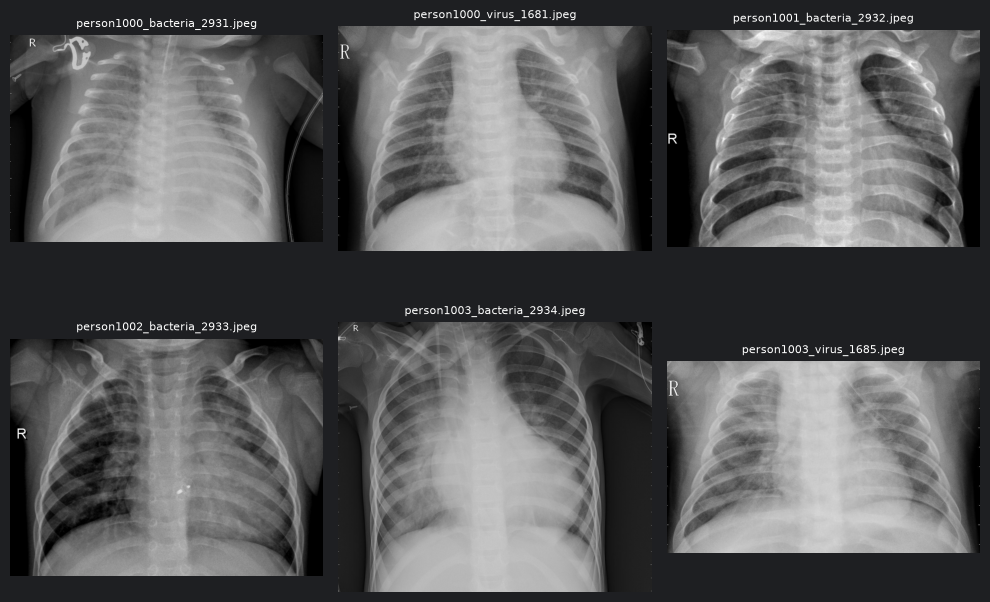

In [7]:
# Display up to six training images labelled PNEUMONIA.
pneumonia_paths = [
    filepath for filepath, label in zip(train_generator.filepaths, train_generator.classes)
    if label == 1
]
if not pneumonia_paths:
    print("No PNEUMONIA images were found in the training split.")
else:
    fig, axes = plt.subplots(2, 3, figsize=(10, 7))
    for ax, filepath in zip(axes.flat, pneumonia_paths[:6]):
        ax.imshow(plt.imread(filepath), cmap="gray")
        ax.set_title(Path(filepath).name, fontsize=8)
        ax.axis("off")
    for ax in list(axes.flat)[len(pneumonia_paths[:6]):]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()

**Plotting :** Images without Pneumonia from dataset.

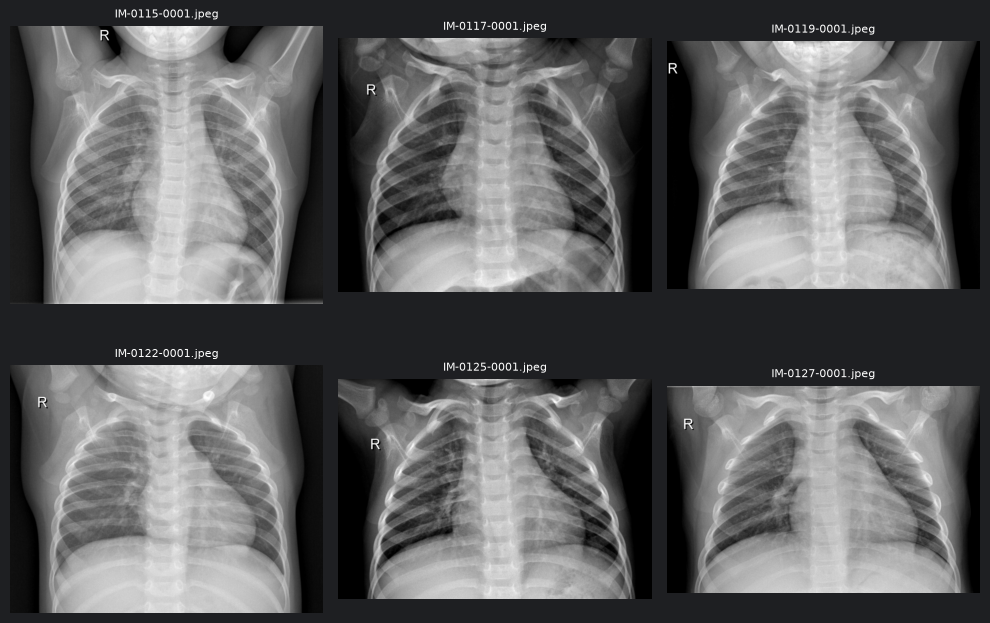

In [8]:
# Display up to six training images labelled NORMAL.
normal_paths = [
    filepath for filepath, label in zip(train_generator.filepaths, train_generator.classes)
    if label == 0
]
if not normal_paths:
    print("No NORMAL images were found in the training split.")
else:
    fig, axes = plt.subplots(2, 3, figsize=(10, 7))
    for ax, filepath in zip(axes.flat, normal_paths[:6]):
        ax.imshow(plt.imread(filepath), cmap="gray")
        ax.set_title(Path(filepath).name, fontsize=8)
        ax.axis("off")
    for ax in list(axes.flat)[len(normal_paths[:6]):]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()

<h2><b> Convolutional Neural Network</b></h2>

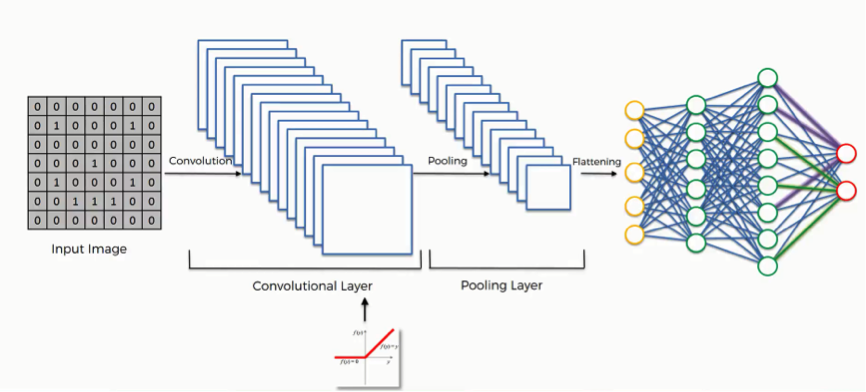

CNN consists of Convolutional layers, pooling layers.

ANN consists of hidden layers and output layers.

To develop the model I have used 5 Conv2D layers which are followed by maxpooling layers for every Conv2D layer.

Then for classification Artificial Neural Network with 2 hidden layers and one output layer which has a single neuron is used.




**Activation function :**

ReLU is used in the hidden layers and Conv2D layers.

Sigmoid is used because the output we need is of binary classification.

**Loss function :** Binary cross entropy is used.

**Optimizer :** Adam optimizer is used because it gives best result.

<h1>Neural Networks using TensorFlow</h1>

Metrics : Accuracy.

In [9]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),
    tf.keras.layers.Conv2D(16, (3, 3), activation="relu"),
    tf.keras.layers.MaxPool2D(2, 2),
    tf.keras.layers.Conv2D(32, (3, 3), activation="relu"),
    tf.keras.layers.MaxPool2D(2, 2),
    tf.keras.layers.Conv2D(64, (3, 3), activation="relu"),
    tf.keras.layers.MaxPool2D(2, 2),
    tf.keras.layers.Conv2D(128, (3, 3), activation="relu"),
    tf.keras.layers.MaxPool2D(2, 2),
    tf.keras.layers.Conv2D(128, (3, 3), activation="relu"),
    tf.keras.layers.MaxPool2D(2, 2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(256, activation="relu"),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(512, activation="relu"),
    tf.keras.layers.Dropout(0.5),
    # Sigmoid output estimates P(PNEUMONIA); values >= 0.5 are classified as PNEUMONIA.
    tf.keras.layers.Dense(1, activation="sigmoid")
])

model.summary()
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 298, 298, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 149, 149, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 147, 147, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 73, 73, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 71, 71, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 35, 35, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 33, 33, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 14, 14, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,605,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,983,009 (7.56 MB)

 Trainable params: 1,983,009 (7.56 MB)

 Non-trainable params: 0 (0.00 B)

**Training the model for 50 epochs**

In [10]:
callbacks = [
    ModelCheckpoint(
        filepath=str(MODEL_PATH),
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),
    EarlyStopping(
        monitor="val_loss",
        patience=7,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    )
]

history = model.fit(
    train_generator,
    epochs=50,
    validation_data=validation_generator,
    callbacks=callbacks
)

Epoch 1/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 808ms/step - accuracy: 0.7395 - loss: 0.5758  
Epoch 1: val_loss improved from None to 0.81419, saving model to C:\Users\RAKESH\PycharmProjects\CCL_Project\trained.h5



Epoch 1: finished saving model to C:\Users\RAKESH\PycharmProjects\CCL_Project\trained.h5
163/163 ━━━━━━━━━━━━━━━━━━━━ 134s 812ms/step - accuracy: 0.7395 - loss: 0.5758 - val_accuracy: 0.6250 - val_loss: 0.8142 - learning_rate: 1.0000e-04
Epoch 2/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 796ms/step - accuracy: 0.8668 - loss: 0.3071  
Epoch 2: val_loss improved from 0.81419 to 0.43053, saving model to C:\Users\RAKESH\PycharmProjects\CCL_Project\trained.h5



Epoch 2: finished saving model to C:\Users\RAKESH\PycharmProjects\CCL_Project\trained.h5
163/163 ━━━━━━━━━━━━━━━━━━━━ 130s 797ms/step - accuracy: 0.8668 - loss: 0.3071 - val_accuracy: 0.8125 - val_loss: 0.4305 - learning_rate: 1.0000e-04
Epoch 3/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 759ms/step - accuracy: 0.9141 - loss: 0.2224  
Epoch 3: val_loss did not improve from 0.43053
163/163 ━━━━━━━━━━━━━━━━━━━━ 124s 760ms/step - accuracy: 0.9141 - loss: 0.2224 - val_accuracy: 0.6875 - val_loss: 0.8601 - learning_rate: 1.0000e-04
Epoch 4/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 745ms/step - accuracy: 0.9172 - loss: 0.2119  
Epoch 4: val_loss did not improve from 0.43053
163/163 ━━━━━━━━━━━━━━━━━━━━ 122s 746ms/step - accuracy: 0.9172 - loss: 0.2119 - val_accuracy: 0.6875 - val_loss: 0.6576 - learning_rate: 1.0000e-04
Epoch 5/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 741ms/step - accuracy: 0.9262 - loss: 0.1880  
Epoch 5: val_loss did not improve from 0.43053

Epoch 5: ReduceLROnPlateau reducing learning rate t

**Training results:** The training and validation plots below are generated from the current run. Do not use fixed accuracy values from a previous run as results for this model.

In [11]:
loss = history.history['loss']
val_loss = history.history['val_loss']

**<h3>Plotting Loss Vs Num. of Epochs</h3>**

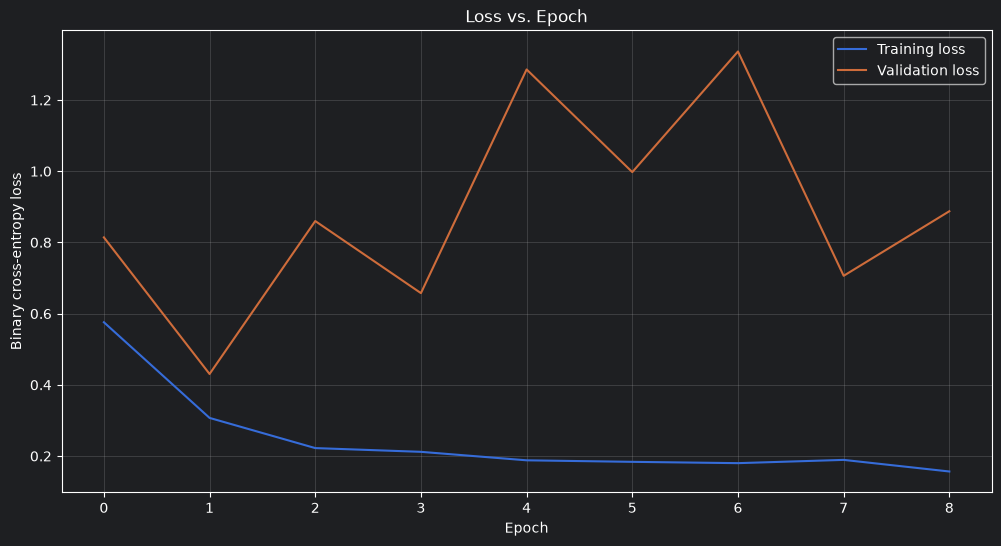

In [12]:
plt.figure(figsize=(12, 6))
plt.plot(history.history["loss"], label="Training loss")
plt.plot(history.history["val_loss"], label="Validation loss")
plt.title("Loss vs. Epoch")
plt.xlabel("Epoch")
plt.ylabel("Binary cross-entropy loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [13]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

**<h3>Plotting Accuracy Vs Num. of Epochs</h3>**

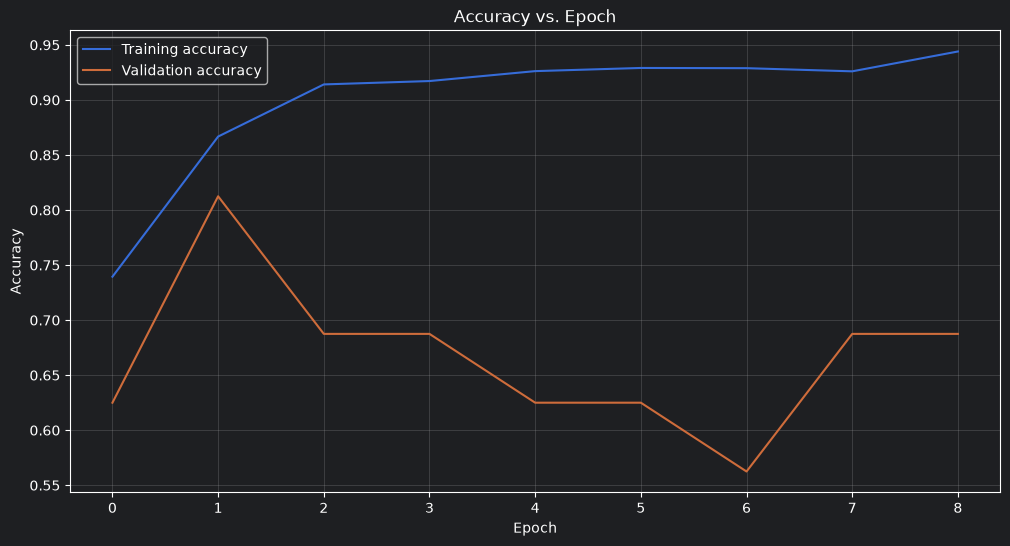

In [14]:
plt.figure(figsize=(12, 6))
plt.plot(history.history["accuracy"], label="Training accuracy")
plt.plot(history.history["val_accuracy"], label="Validation accuracy")
plt.title("Accuracy vs. Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

<h3>Saving the model</h3>

In [15]:
# Save the model in the current working directory.
model.save(str(MODEL_PATH))
print("Model saved to:", MODEL_PATH.resolve())

Model saved to: C:\Users\RAKESH\PycharmProjects\CCL_Project\trained.h5


<h3>Loading the saved model so that we can load the model which is already saved so lot of time can be saved and it can also be used for deployment.</h3>

In [16]:
# Reload the saved model to verify that it can be loaded for later inference.
model = tf.keras.models.load_model(str(MODEL_PATH))
print("Model loaded from:", MODEL_PATH.resolve())

Model loaded from: C:\Users\RAKESH\PycharmProjects\CCL_Project\trained.h5


**Loading the test data generator**

In [17]:
test_generator = eval_datagen.flow_from_directory(
    str(TEST_DIR),
    classes=CLASS_NAMES,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

print("Test class mapping:", test_generator.class_indices)
assert test_generator.class_indices == {"NORMAL": 0, "PNEUMONIA": 1}

test_loss, test_accuracy = model.evaluate(test_generator, verbose=1)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f} ({test_accuracy * 100:.2f}%)")

# Additional class-wise metrics, using predictions in the same order as test_generator.classes.
from sklearn.metrics import classification_report, confusion_matrix

test_probabilities = model.predict(test_generator, verbose=1).ravel()
test_predictions = (test_probabilities >= 0.5).astype(int)
print("\nClassification report (0 = NORMAL, 1 = PNEUMONIA):")
print(classification_report(
    test_generator.classes,
    test_predictions,
    labels=[0, 1],
    target_names=CLASS_NAMES,
    zero_division=0
))
print("Confusion matrix (rows = actual, columns = predicted):")
print(confusion_matrix(test_generator.classes, test_predictions, labels=[0, 1]))

Found 624 images belonging to 2 classes.
Test class mapping: {'NORMAL': 0, 'PNEUMONIA': 1}
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 258ms/step - accuracy: 0.8542 - loss: 0.3357 
Test loss: 0.3357
Test accuracy: 0.8542 (85.42%)
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 234ms/step 

Classification report (0 = NORMAL, 1 = PNEUMONIA):
              precision    recall  f1-score   support

      NORMAL       0.80      0.81      0.81       234
   PNEUMONIA       0.89      0.88      0.88       390

    accuracy                           0.85       624
   macro avg       0.84      0.85      0.84       624
weighted avg       0.85      0.85      0.85       624

Confusion matrix (rows = actual, columns = predicted):
[[190  44]
 [ 47 343]]


Test-set performance is calculated by the evaluation cell above each time the notebook is run. The result may differ from earlier runs and should be reported only after evaluating the final model.

**An image is used from drive for prediction**

In [18]:
# Define one reusable function for predicting a single chest X-ray image.
from PIL import Image

def predict_xray(image_path, threshold=0.5):
    image_path = Path(image_path)
    if not image_path.is_file():
        raise FileNotFoundError(f"Image not found: {image_path}")

    with Image.open(image_path) as source:
        display_image = source.convert("RGB")
        resized_image = display_image.resize(IMG_SIZE)

    image_array = np.asarray(resized_image, dtype=np.float32) / 255.0
    image_array = np.expand_dims(image_array, axis=0)

    pneumonia_probability = float(model.predict(image_array, verbose=0)[0][0])
    predicted_label = "PNEUMONIA" if pneumonia_probability >= threshold else "NORMAL"
    confidence = (
        pneumonia_probability if predicted_label == "PNEUMONIA"
        else 1.0 - pneumonia_probability
    )

    plt.figure(figsize=(5, 5))
    plt.imshow(display_image)
    plt.title(
        f"Predicted: {predicted_label}\n"
        f"Model score for pneumonia: {pneumonia_probability:.3f}\n"
        f"Predicted-class score: {confidence * 100:.1f}%",
        fontsize=11
    )
    plt.axis("off")
    plt.show()

    print("Predicted label:", predicted_label)
    print(f"Model score for PNEUMONIA: {pneumonia_probability:.4f}")
    print(
        "Note: This is an educational model output, not a medical diagnosis. "
        "Confidence is not a measure of clinical certainty."
    )
    return pneumonia_probability

The model output is a sigmoid score interpreted as the model's estimated probability for the **PNEUMONIA** class. A threshold of 0.5 is used here for demonstration; this threshold has not been clinically validated.

Example image: C:\Users\RAKESH\PycharmProjects\CCL_Project\chest_xray\test\NORMAL\IM-0001-0001.jpeg


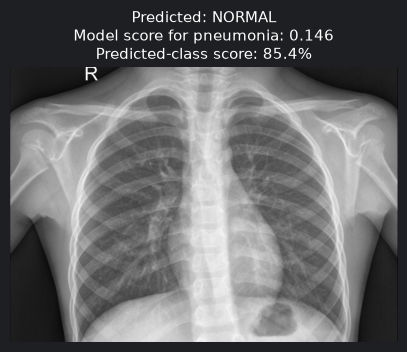

Predicted label: NORMAL
Model score for PNEUMONIA: 0.1458
Note: This is an educational model output, not a medical diagnosis. Confidence is not a measure of clinical certainty.


In [19]:
# Choose an example NORMAL image automatically from the test split.
normal_test_paths = sorted((TEST_DIR / "NORMAL").glob("*"))
if normal_test_paths:
    normal_example = normal_test_paths[0]
    print("Example image:", normal_example)
    predict_xray(normal_example)
else:
    print("No images were found in the test/NORMAL folder.")

Example image: C:\Users\RAKESH\PycharmProjects\CCL_Project\chest_xray\test\PNEUMONIA\person100_bacteria_475.jpeg


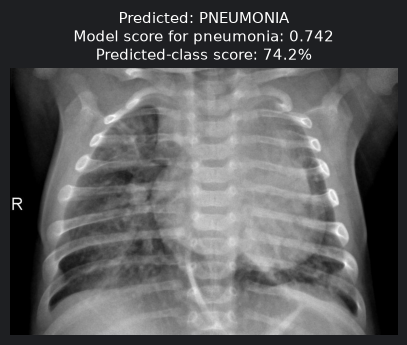

Predicted label: PNEUMONIA
Model score for PNEUMONIA: 0.7421
Note: This is an educational model output, not a medical diagnosis. Confidence is not a measure of clinical certainty.


In [20]:
# Choose an example PNEUMONIA image automatically from the test split.
pneumonia_test_paths = sorted((TEST_DIR / "PNEUMONIA").glob("*"))
if pneumonia_test_paths:
    pneumonia_example = pneumonia_test_paths[0]
    print("Example image:", pneumonia_example)
    predict_xray(pneumonia_example)
else:
    print("No images were found in the test/PNEUMONIA folder.")

The examples above are selected from the test folders and their predictions are generated by the current trained model. A single correct prediction does not establish overall model performance; use the full test-set metrics above.

In [21]:
# You can also test another image by changing this path:
# custom_image_path = Path("path/to/your/chest_xray_image.jpeg")
# predict_xray(custom_image_path)

<h2>Conclusion</h2>

This notebook demonstrates a CNN-based image-classification workflow for chest X-rays. Its predictions are for educational and experimental use only. The model has not been established as clinically validated and must not be used to diagnose, rule out, or make treatment decisions about pneumonia. Any real clinical use would require appropriate medical oversight, external validation, bias and safety evaluation, and regulatory review.